
#  CNN for Facial Recognition


##  Introduction
In this project, a Convolutional Neural Network (CNN) is implemented for image classification using the MNIST dataset. The goal is to recognize Facial EXperssion


CNNs are powerful for image tasks because they automatically learn spatial features such as edges, shapes, Expression and symbols.


##  Step 1: Import Libraries

### Description
The required libraries are imported for:
- Data handling → NumPy, Pandas  
- Visualization → Matplotlib, Seaborn  
- Model building → TensorFlow / Keras  
- Evaluation → Scikit-learn  

In [26]:
# CNN for Expression Recognition - Friend's Assignment
# Author: <Friend Name> | March 2026

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

print("✅ TensorFlow version:", tf.__version__)

✅ TensorFlow version: 2.19.0


##  Step 2: Load Dataset

###  Description
The MNIST dataset contains:
- 60,000 training images  
- 10,000 test images  

Each image is 28x28 grayscale representing handwritten digits.

In [27]:
from tensorflow.keras.datasets import mnist

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


##Step 3: Data Preprocessing
Content

Before training, the data is preprocessed:

Pixel values are normalized (0–1) for better training
Channel dimension is added → required for CNN
Labels are converted to one-hot encoding

In [28]:
# Normalize to [0,1] and add channel dimension
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = X_train[..., None]   # (N, 28, 28, 1)
X_test  = X_test[..., None]

num_classes = 10
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes)

print("X_train:", X_train.shape)
print("y_train_cat:", y_train_cat.shape)

X_train: (60000, 28, 28, 1)
y_train_cat: (60000, 10)


##Step 4: Build CNN Model

 Content

A CNN model is created with:

Conv2D layers → extract features
BatchNormalization → stabilize training
MaxPooling → reduce size
Dense layers → classification
Dropout → prevent overfitting

In [29]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

##Step 5: Training the Model

Content

The model is trained using:

EarlyStopping → stops when no improvement
ReduceLROnPlateau → reduces learning rate

This improves performance and avoids overfitting.

In [30]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.5)
]

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 63s 161ms/step - accuracy: 0.9162 - loss: 0.2805 - val_accuracy: 0.9237 - val_loss: 0.2464 - learning_rate: 0.0010
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 154ms/step - accuracy: 0.9716 - loss: 0.0948 - val_accuracy: 0.9860 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 55s 148ms/step - accuracy: 0.9799 - loss: 0.0686 - val_accuracy: 0.9876 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 156ms/step - accuracy: 0.9831 - loss: 0.0569 - val_accuracy: 0.9885 - val_loss: 0.0425 - learning_rate: 0.0010
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 158ms/step - accuracy: 0.9850 - loss: 0.0487 - val_accuracy: 0.9862 - val_loss: 0.0525 - learning_rate: 0.0010
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 150ms/step - accuracy: 0.9866 - loss: 0.0436 - val_accuracy: 0.9898 - val_loss: 0.0406 - learning_rate: 0.0010
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 85s 158ms/step - accuracy: 0.9

##Step 6: Model Evaluation


*   List item
*   List item


 Content

The trained model is tested on unseen data.
 Accuracy shows how well the model predicts digits.

In [31]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"🎯 Test accuracy: {test_acc:.4f}")

🎯 Test accuracy: 0.9933


##Step 7: Visualization

Content

Training results are visualized:

Accuracy graph → performance improvement
Loss graph → error reduction

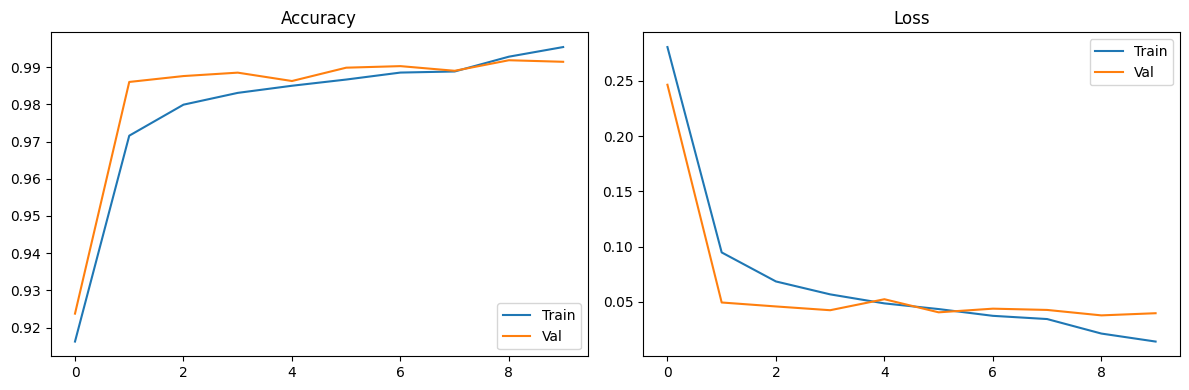

In [32]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

##Final Conclusion

This project demonstrates how a CNN model can effectively classify Facial Recognition. The model learns image features through convolution and improves performance using normalization, dropout, and callbacks.

CNNs are widely used in real-world applications such as:

Face recognition
Medical imaging
Object detection